In [8]:
import numpy as np
import matplotlib.pyplot as plt
import re

sequences = {
    "mioglobin": 'MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG',
    "mastermind": 'MDDWKSRLVIKSMLPHFAMVGNRQEPRKLQESGKKPSWMEEEDLSFLYKSSPGRKHQGTVKRRQEEDHFQFPDMADGGYPNKIKRPCLEDVTLAMGPGAHPSTACAELQVPPLTINPSPAAMGVAGQSLLLENNPMNGNIMGSPFVVPQTTEVGLKGPTVPYYEKINSVPAVDQELQELLEELTKIQDPSPNELDLEKILGTKPEEPLVLDHPQATLSTTPKPSVQMSHLESLASSKEFASSCSQVTGMSLQIPSSSTGISYSIPSTSKQIVSPSSSMAQSKSQVQAMLPVALPPLPVPQWHHAHQLKALAASKQGSATKQQGPTPSWSGLPPPGLSPPYRPVPSPHPPPLPLPPPPPPFSPQSLMVSCMSSNTLSGSTLRGSPNALLSSMTSSSNAALGPAMPYAPEKLPSPALTQQPQFGPQSSILANLMSSTIKTPQGHLMSALPASNPGPSPPYRPEKLSSPGLPQQSFTPQCSLIRSLTPTSNLLSQQQQQQQQQQQANVIFKPISSNSSKTLSMIMQQGMASSSPGATEPFTFGNTKPLSHFVSEPGPQKMPSMPTTSRQPSLLHYLQQPTPTQASSATASSTATATLQLQQQQQQQQQQPDHSSFLLQQMMQQPQRFQRSVASDSMPALPRQGCCHLFAWTSAASSVKPQHQHGNSFTSRQDPQPGDVSPSNITHVDKACKLGEARHPQVSLGRQPPSCQALGSESFLPGSSFAHELARVTSSYSTSEAAPWGSWDPKAWRQVPAPLLPSCDATARGTEIRSYGNDP',
    "fus": 'MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYGQSSYSSYGQSQNTGYGTQSTPQGYGSTGGYGSSQSSQSSYGQQSSYPGYGQQPAPSSTSGSYGSSSQSSSYGQPQSGSYSQQPSYGGQQQSYGQQQSYNPPQGYGQQNQYNSSSGGGGGGGGGGNYGQDQSSMSSGGGSGGGYGNQDQSGGGGSGGYGQQDRGGRGRGGSGGGGGGGGGGYNRSSGGYEPRGRGGGRGGRGGMGGSDRGGFNKFGGPRDQGSRHDSEQDNSDNNTIFVQGLGENVTIESVADYFKQIGIIKTNKKTGQPMINLYTDRETGKLKGEATVSFDDPPSAKAAIDWFDGKEFSGNPIKVSFATRRADFNRGGGNGRGGRGRGGPMGRGGYGGGGSGGGGRGGFPSGGGGGGGQQRAGDWKCPNPTCENMNFSWRNECNQCKAPKPDGPGGGPGGSHMGGNYGDDRRGGRGGYDRGGYRGRGGDRGGFRGGRGGGDRGGFGPGKMDSRGEHRQDRRERPY',
    "query_t": 'MNLLLILTFVAAAVAAPFDDDDKIVGGYICEENSVPYQVSLNSGYHFCGGSLISEQWVVSAGHCYKSRIQVRLGEHNIEVLEGNEQFINAAKIIRHPKYNSRTLDNDILLIKLSSPAVINSRVSAISLPTAPPAAGTESLISGWGNTLSSGADYPDELQCLDAPVLSQAECEASYPGKITNNMFCVGFLEGGKDSCQGDSGGPVVSNGELQGIVSWGYGCAQKNRPGVYTKVYNYVDWIKDTIAANS',
    "query_s": 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA',
    "query_m": 'MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPGSETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAGHVTQARMVSKSKDGTGSDDKKAKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPKTPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAKSRLQTAPVPMPDLKNVKSKIGSTENLKHQPGGGKVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKLDFKDRVQSKIGSLDNITHVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPVVSGDTSPRHLSNVSSTGSIDMVDSPQLATLADEVSASLAKQGL',
    "query_a": 'MELDHRTSGGLHAYPGPRGGQVAKPNVILQIGKCRAEMLEHVRRTHRHLLAEVSKQVERELKGLHRSVGKLESNLDGYVPTSDSQRWKKSIKACLCRCQETIANLERWVKREMHVWREVFYRLERWADRLESTGGKYPVGSESARHTVSVGVGGPESYCHEADGYDYTVSPYAITPPPAAGELPGQEPAEAQQYQPWVPGEDGQPSPGVDTQIFEDPREFLSHLEEYLRQVGGSEEYWLSQIQNHMNGPAKKWWEFKQGSVKNWVEFKKEFLQYSEGTLSREAIQRELDLPQKQGEPLDQFLWRKRDLYQTLYVDADEEEIIQYVVGTLQPKLKRFLRHPLPKTLEQLIQRGMEVQDDLEQAAEPAGPHLPVEDEAETLTPAPNSESVASDRTQPE'
}


def shannon_entropy(sequence:np.array):
    n = len(sequence)
    uniques, counts = np.unique(sequence, return_counts = True)
    return - np.sum(np.log2(counts/n) * (counts/n))


def sliding_window_entropy(sequence:np.array, window_length = 21):
    n = len(sequence)
    n_slices = n // window_length
    if (n % window_length != 0):
        n_slices += 1   # last slice could be shorter
    results = np.zeros(n_slices)
    start_idxs = np.array([idx * window_length for idx in range(n_slices)])
    for idx in range(n_slices):
        start_idx = idx * window_length
        end_idx = (idx + 1) * window_length
        results[idx] = shannon_entropy(sequence[start_idx:end_idx])
    return start_idxs, results

**Visually** (before doing any computation)

- **QUERY_T** appears to contain many different letters and few repetitions (high entropy = high information = high complexity). I expect a quite ordered structure (e.g. helices). Also there are $C$ residues in various points inside the structure. These form disulfide bridges so I expect that they stabilize the structure. 

- **QUERY_S**: more repetitions (e.g. AAA, KK, EE, VV) and fewer letters represented. Many *non* polar aminoacids. Maybe the protein will be compact, but not in an ordered way.

- **QUERY_M**: : there are some repetitions (KK, 
SS, PP). There is a lot of Proline P with respect to the other sequences. Proline adds rigidity, so... ? 

- **QUERY_A**: I dont know honestly.... A lot of Q (some QQ too)... Some WW,,KK...


In [5]:
def count_repetitions(seq):
    matches = [m.group(0) for m in re.finditer(r'(.)\1+', seq)]
    return len(matches), matches

print(f"{'Sequence':<12} | {'Entropy':<5} | {'Count/Length':<8} | {'Repetitions Found':<15}|")
print("-" * 90)


for name, seq in sequences.items():
    entropy = shannon_entropy(np.array(list(seq)))
    count, reps = count_repetitions(seq)
    ratio = np.sum([len(rep) for rep in reps]) / len(seq)
    unique_reps = sorted(np.unique(reps), key=len, reverse=True)
    
    reps_str = ", ".join(unique_reps)
    print(f"{name:<12} |{entropy:<5.4f} | {ratio:<8.3f} | {reps_str}")




print(f"Maximum reacheable entropy (20 amino-acids): {np.log2(20):.4f}")

Sequence     | Entropy | Count/Length | Repetitions Found|
------------------------------------------------------------------------------------------
mioglobin    |3.9918 | 0.071    | KKK, GG, HH, II, KK
mastermind   |3.9573 | 0.208    | QQQQQQQQQQQ, QQQQQQQQQQ, PPPPPP, EEE, LLL, PPP, SSS, AA, CC, DD, EE, GG, HH, KK, LL, MM, NN, PP, QQ, RR, SS, TT, VV, YY
fus          |3.5224 | 0.346    | GGGGGGGGGG, GGGGGGG, GGGG, GGG, QQQ, SSS, AA, DD, GG, II, KK, NN, PP, QQ, RR, SS
query_t      |4.1072 | 0.178    | DDDD, AAA, LLL, AA, EE, GG, II, LL, NN, PP, SS, VV
query_s      |3.6525 | 0.157    | AAA, AA, EE, GG, KK, VV
query_m      |3.9190 | 0.147    | AAA, GGG, AA, DD, EE, GG, HH, II, KK, PP, SS, TT, VV
query_a      |4.1072 | 0.111    | EEE, PPP, AA, DD, EE, GG, II, KK, LL, QQ, RR, VV, WW
Maximum reacheable entropy (20 amino-acids): 4.3219


Differently from mastermind and fus, in the four unknown sequences there are not huge repetitions.

- *query_t*: Lot of repeated non polar ones (D, A, L, G, I, P, V) some ambigue  (S) and some polars (D, N, E). Very high shannon entropy, so this could be a highly specialized protein like an enzyme.

- *query_s*:  again, some repetitions of non-polars (A, G, V) but also two very polar ones (E, K). Very low entropy.

- *query_m*: D, E, H, K, S, T.  I dont know what this could be.

- *query_a*: D, E, H, K, S, T.  I dont know what this could be.

## Windowed shannon entropy

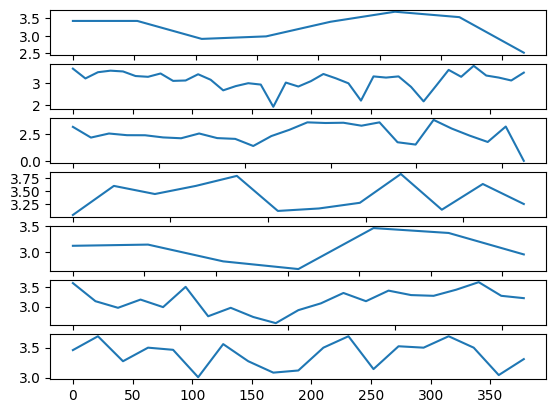

In [12]:
fig, axs = plt.subplots(nrows = len(sequences.items()))
i = -1
for name, seq in sequences.items():
    i+=1
    start_idxs,slice_entropy = sliding_window_entropy(np.array(list(seq)))
    axs[i].plot(start_idxs, slice_entropy)

Wiki: https://en.wikipedia.org/wiki/Hydrophilicity_plot

KYTE-DOOLITTLE SCALE

more positive value = more hydrophobic

Hydrophobicity:
mioglobin, mean: -0.47597402597402594, polar fraction : 0.6363636363636364


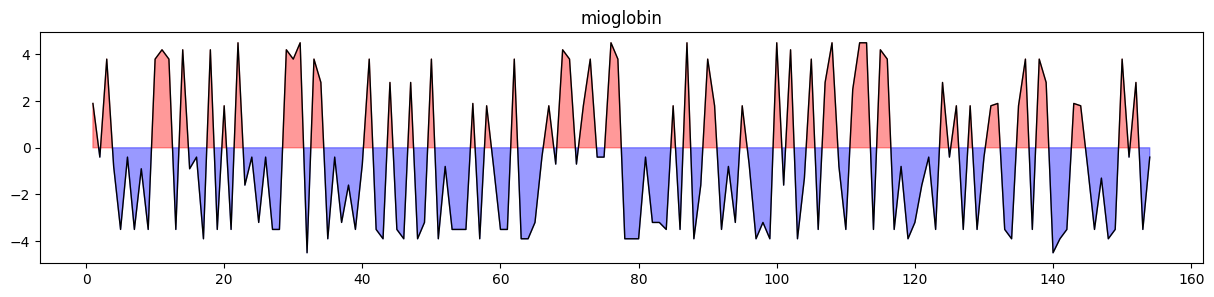

mastermind, mean: -0.5502583979328166, polar fraction : 0.7028423772609819


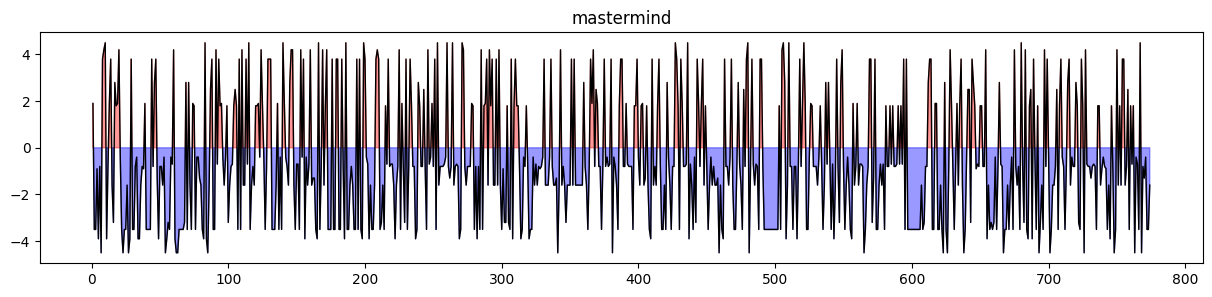

fus, mean: -1.3193916349809887, polar fraction : 0.8973384030418251


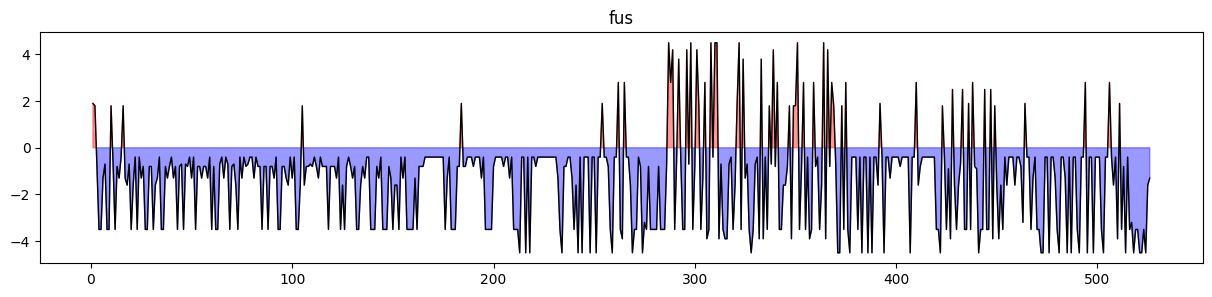

query_t, mean: -0.06234817813765186, polar fraction : 0.6234817813765182


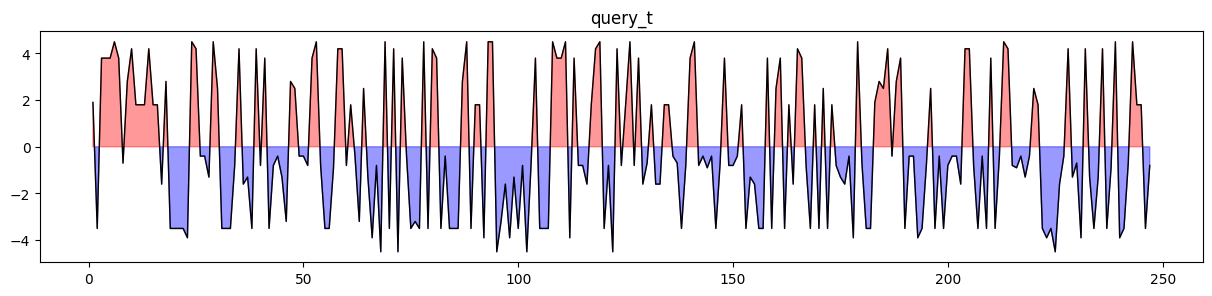

query_s, mean: -0.4028571428571428, polar fraction : 0.6428571428571429


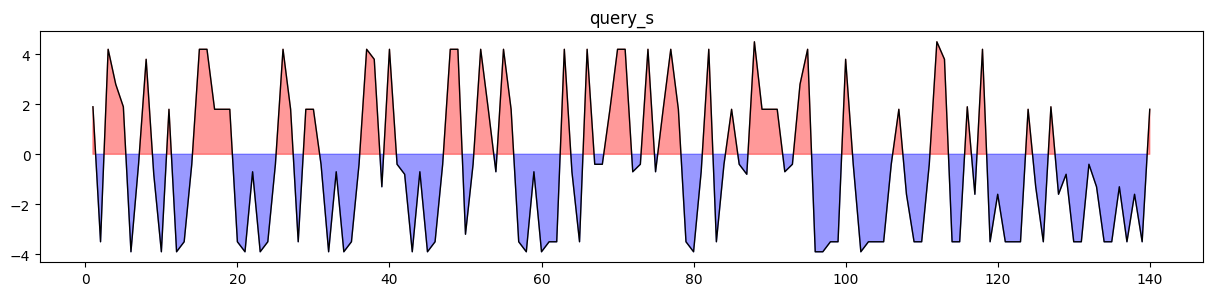

query_m, mean: -0.8678004535147393, polar fraction : 0.7551020408163265


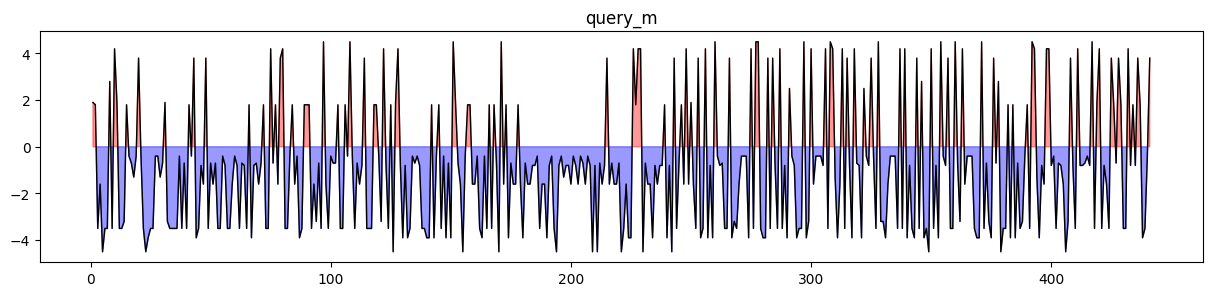

query_a, mean: -0.8161616161616161, polar fraction : 0.7121212121212122


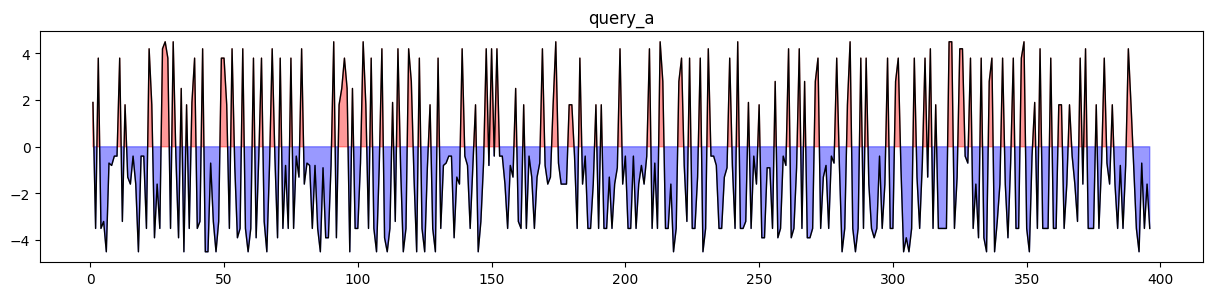

In [102]:
scale = {
'I': 4.5,
'V': 4.2,
'L': 3.8,
'F': 2.8,
'C': 2.5,
'M': 1.9,
'A':	1.8,
'G':	-0.4,
'T':	-0.7,
'S':	-0.8,
'W':	-0.9,
'Y':	-1.3,
'P':	-1.6,
'H':	-3.2,
'E':	-3.5,
'Q':	-3.5,
'D':	-3.5,
'N':	-3.5,
'K':	-3.9,
'R':	-4.5
}

print("Hydrophobicity:")

for name, seq in sequences.items():
    hp_vals = np.array([scale[aa] for aa in list(seq)], dtype = float)
    print(f"{name}, mean: {np.mean(hp_vals)}, polar fraction : {np.sum(hp_vals < 0)/len(seq)}")

    x = np.arange(1, len(hp_vals) + 1)
    plt.figure(figsize = (15, 3))
    plt.title(name)
    plt.fill_between(x, hp_vals, 0, where=(hp_vals >= 0), color='red', alpha=0.4, interpolate=True)
    plt.fill_between(x, hp_vals, 0, where=(hp_vals < 0), color='blue', alpha=0.4, interpolate=True)
    plt.plot(x, hp_vals, color='black', linewidth=1)
    plt.show()

The first two (query_t, query_s) have relatively low polarity (mean ~ -0.4, polar fraction ~ 0.6), similiarly to mioglobin.

Instead the second two (query_m, query_a) are more polar, so they stand more towards mastermind-fus.



query_m has long uninterrupted regions of polar residues, while in query_a there is a faster alternance of polar and non polar.